# Working with 3D Gaussian Splat Models

This notebook demonstrates key features of Kaolin's `GaussianSplatModel` — a data container for **3D Gaussian Splatting** representations. We'll walk through reading and writing models from PLY and USD formats, inspecting their contents, moving tensors between devices, applying spatial transforms, concatenating scenes, and filtering by opacity.

**Sections:**
- [Reading from/to USD and PLY](#Reading-from/to-USD-and-PLY)
- [Inspecting a GaussianSplatModel](#Inspecting-a-GaussianSplatModel)
- [Tensor Management](#Tensor-Management)
- [Applying Transforms](#Applying-Transforms)
- [Concatenating Gaussian Models](#Concatenating-Gaussian-Models)
- [Masking and Filtering](#Masking-and-Filtering)

In [1]:
import copy
import gsplat.rendering
import math
import os
import torch

import kaolin
from kaolin.rep import GaussianSplatModel
from kaolin.render.camera import kaolin_camera_to_gsplat_nerfstudio
from kaolin.utils.bundled_data import SCANNED_TOYS_PATH, SCANNED_TOYS_NAMES, download_scanned_toys_dataset
from kaolin.utils.log import log_tensor
from kaolin.visualize.ipython import quick_viz

%matplotlib inline
device = 'cuda'

In [ ]:
!pip install -q matplotlib
!pip install gsplat

In [3]:
download_scanned_toys_dataset()  # only re-downloads if needed

TOY_A = SCANNED_TOYS_NAMES[0]  # 'BluehairRagdoll'
TOY_B = SCANNED_TOYS_NAMES[1]  # 'bublik_octopus'

### Reading from/to USD and PLY

`kaolin.io.import_gaussiancloud` auto-detects the file format (PLY or USD/USDC). Both formats store the same Gaussian attributes; USD additionally supports scene hierarchy and transforms.

In [4]:
# Load from PLY
ply_path = os.path.join(SCANNED_TOYS_PATH, f'{TOY_A}.ply')
gsmodel_a = kaolin.io.import_gaussiancloud(ply_path).to(device)

# Load from USD
usd_path = os.path.join(SCANNED_TOYS_PATH, f'{TOY_A}.usdc')
gsmodel_a_usd = kaolin.io.import_gaussiancloud(usd_path).to(device)

print(f'Loaded from PLY: {len(gsmodel_a)} Gaussians')
print(f'Loaded from USD: {len(gsmodel_a_usd)} Gaussians')

Loaded from PLY: 155290 Gaussians
Loaded from USD: 155290 Gaussians


In [5]:
# Export to PLY (works seamlessly with individual tensor attributes)
out_ply = os.path.join('/tmp', f'{TOY_A}_roundtrip.ply')
kaolin.io.ply.export_gaussiancloud(
    out_ply,
    positions=gsmodel_a.positions,
    orientations=gsmodel_a.orientations,
    scales=gsmodel_a.scales,
    opacities=gsmodel_a.opacities,
    sh_coeff=gsmodel_a.sh_coeff,
    overwrite=True
)
print(f'Saved to {out_ply}')

# Verify roundtrip
gsmodel_roundtrip = kaolin.io.import_gaussiancloud(out_ply)
print(f'Roundtrip: {len(gsmodel_roundtrip)} Gaussians (original: {len(gsmodel_a)})')

Saved to /tmp/BluehairRagdoll_roundtrip.ply
Roundtrip: 155290 Gaussians (original: 155290)


### Inspecting a GaussianSplatModel

`print()` gives a compact summary. `to_string(print_stats=True)` adds per-tensor statistics (min, max, mean) — useful for spotting scaling issues or NaNs.

In [6]:
print(gsmodel_a)

GaussianSplatModel of 155290 (sh_degree=3)
           positions: [155290, 3] (torch.float32)[cuda:0]  
        orientations: [155290, 4] (torch.float32)[cuda:0]  
              scales: [155290, 3] (torch.float32)[cuda:0]  
           opacities: [155290] (torch.float32)[cuda:0]  
            sh_coeff: [155290, 16, 3] (torch.float32)[cuda:0]  
           sh_degree: 3


In [7]:
print(gsmodel_a.to_string(print_stats=True))
print(f'Number of Gaussians: {len(gsmodel_a)}')
print(f'SH degree: {gsmodel_a.sh_degree}')

GaussianSplatModel of 155290 (sh_degree=3)
           positions: [155290, 3] (torch.float32)[cuda:0]  
                        x - [min -0.1956, max 0.2197, mean 0.0000]
                        y - [min -0.1107, max 0.1773, mean 0.0000]
                        z - [min -0.0178, max 0.9822, mean 0.3800]
        orientations: [155290, 4] (torch.float32)[cuda:0]  - [min -0.9999, max 0.9122, mean -0.3894] 
              scales: [155290, 3] (torch.float32)[cuda:0]  - [min 0.0000, max 0.0560, mean 0.0015] 
           opacities: [155290] (torch.float32)[cuda:0]  - [min 0.0014, max 1.0000, mean 0.5046] 
            sh_coeff: [155290, 16, 3] (torch.float32)[cuda:0]  - [min -2.1986, max 3.4715, mean -0.0128] 
           sh_degree: 3
Number of Gaussians: 155290
SH degree: 3


### Tensor Management

`GaussianSplatModel` supports the same `.to()`, `.cuda()`, `.cpu()` API as `torch.nn.Module`, applied to all tensor attributes at once. `check_sanity()` validates internal consistency of shapes and dtypes.

In [18]:
gsmodel_cpu = gsmodel_a.cpu()
print('After .cpu():')
print(gsmodel_cpu.to_string(detailed=True))

gsmodel_back = gsmodel_cpu.cuda()
print('After .cuda():')
print(gsmodel_back.to_string(detailed=True))

After .cpu():
GaussianSplatModel of 155290 (sh_degree=3)
           positions: [155290, 3] (torch.float32)[cpu]   - req_grad=False, is_leaf=True, layout=torch.strided
        orientations: [155290, 4] (torch.float32)[cpu]   - req_grad=False, is_leaf=True, layout=torch.strided
              scales: [155290, 3] (torch.float32)[cpu]   - req_grad=False, is_leaf=True, layout=torch.strided
           opacities: [155290] (torch.float32)[cpu]   - req_grad=False, is_leaf=True, layout=torch.strided
            sh_coeff: [155290, 16, 3] (torch.float32)[cpu]   - req_grad=False, is_leaf=True, layout=torch.strided
           sh_degree: 3
After .cuda():
GaussianSplatModel of 155290 (sh_degree=3)
           positions: [155290, 3] (torch.float32)[cuda:0]   - req_grad=False, is_leaf=True, layout=torch.strided
        orientations: [155290, 4] (torch.float32)[cuda:0]   - req_grad=False, is_leaf=True, layout=torch.strided
              scales: [155290, 3] (torch.float32)[cuda:0]   - req_grad=False, is_lea

In [9]:
# Cast to float16 for memory efficiency
gsmodel_fp16 = gsmodel_a.to(dtype=torch.float16)
log_tensor(gsmodel_fp16.positions, 'positions (fp16)', print_stats=True)
log_tensor(gsmodel_fp16.sh_coeff, 'sh_coeff (fp16)', print_stats=True)

In [10]:
gsmodel_a.check_sanity()
print('Sanity check passed')

Sanity check passed


### Applying Transforms

`as_transformed(transform)` accepts an affine `(4, 4)` matrix and returns a **new** model with positions, orientations, scales, and SH coefficients all consistently updated. The original model is unchanged.

In [11]:
# Build a translation: shift model along X axis by 1.5 units
translation = torch.eye(4, device=device)
translation[0, 3] = 1.5

gsmodel_a_shifted = gsmodel_a.as_transformed(translation)

print('Original centroid:', [f'{v:.4f}' for v in gsmodel_a.positions.mean(0).cpu().tolist()])
print('Shifted centroid: ', [f'{v:.4f}' for v in gsmodel_a_shifted.positions.mean(0).cpu().tolist()])

Original centroid: ['0.0000', '0.0000', '0.3800']
Shifted centroid:  ['1.5000', '0.0000', '0.3800']


### Concatenating Gaussian Models

`GaussianSplatModel.cat()` merges a list of models along the point dimension. Any stored transform on each model is applied first, so the result always has `transform=None`. If models have different SH degrees, the result is capped to the minimum.

In [12]:
# Load second toy and shift it to sit beside TOY_A
ply_path_b = os.path.join(SCANNED_TOYS_PATH, f'{TOY_B}.ply')
gsmodel_b = kaolin.io.import_gaussiancloud(ply_path_b).to(device)

translation_b = torch.eye(4, device=device)
translation_b[0, 3] = -1.5
gsmodel_b_shifted = gsmodel_b.as_transformed(translation_b)

# Concatenate both models into a single scene
combined = GaussianSplatModel.cat([gsmodel_a, gsmodel_b_shifted])
print(f'Combined: {len(combined)} Gaussians (A={len(gsmodel_a)}, B={len(gsmodel_b_shifted)})')
print(combined.to_string(print_stats=True))

Combined: 380893 Gaussians (A=155290, B=225603)
GaussianSplatModel of 380893 (sh_degree=3)
           positions: [380893, 3] (torch.float32)[cuda:0]  
                        x - [min -1.9606, max 0.2197, mean -0.8885]
                        y - [min -0.1899, max 0.1773, mean -0.0000]
                        z - [min -0.0314, max 0.9822, mean 0.4511]
        orientations: [380893, 4] (torch.float32)[cuda:0]  - [min -0.9999, max 0.9993, mean -0.1932] 
              scales: [380893, 3] (torch.float32)[cuda:0]  - [min 0.0000, max 0.0800, mean 0.0017] 
           opacities: [380893] (torch.float32)[cuda:0]  - [min 0.0014, max 1.0000, mean 0.5101] 
            sh_coeff: [380893, 16, 3] (torch.float32)[cuda:0]  - [min -2.9097, max 5.7088, mean -0.0248] 
           sh_degree: 3


Text(0.5, 1.0, 'Combined Scene')

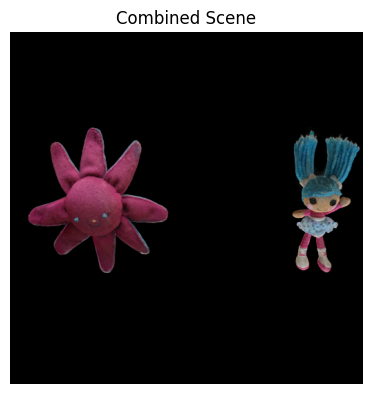

In [19]:
def render_with_gsplat(kal_cam, gsmodel):
    gsplat_cam_params = kaolin_camera_to_gsplat_nerfstudio(kal_cam)
    render_colors, render_alphas, info = gsplat.rendering.rasterization(
        gsmodel.positions,    # [N, 3]
        gsmodel.orientations, # [N, 4]
        gsmodel.scales,       # [N, 3]
        gsmodel.opacities,    # [N]
        gsmodel.sh_coeff,     # [N, S, 3]
        sh_degree=gsmodel.sh_degree,
        **gsplat_cam_params)
    return render_colors, render_alphas, info

center = combined.positions.mean(0)
kaolin_cam = kaolin.render.camera.Camera.from_args(
    eye=center + torch.tensor([0., -2.0, 0.5], device=device),
    at=center,
    up=torch.tensor([0., 0., 1.], device=device),
    fov=math.pi * 60 / 180,
    height=512, width=512).to(device)

colors, alphas, _ = render_with_gsplat(kaolin_cam, combined)
quick_viz(colors.permute(0, 3, 1, 2), inches=10).set_title('Combined Scene')

In [14]:
def tst_render(in_cam):
    colors, _, _ = render_with_gsplat(in_cam, combined)
    return (colors[0] * 255).clip(0, 255).to(torch.uint8)

def tst_render_lowres(in_cam):
    cam = copy.deepcopy(in_cam)
    cam.width = in_cam.width // 4
    cam.height = in_cam.height // 4
    return tst_render(cam)

visualizer = kaolin.visualize.IpyTurntableVisualizer(
    kaolin_cam.height, kaolin_cam.width, copy.deepcopy(kaolin_cam),
    tst_render, fast_render=tst_render_lowres,
    max_fps=24, world_up_axis=2, focus_at=center)
visualizer.show()

Canvas(height=512, width=512)

Output()

### Masking and Filtering

Boolean indexing (`model[mask]`) returns a new `GaussianSplatModel` containing only the selected Gaussians. Here we remove semi-transparent Gaussians (low opacity) to get a cleaner, more compact model, then save to disk.

In [15]:
opacity_threshold = 0.5
mask = combined.opacities > opacity_threshold
print(f'Before masking: {len(combined)} Gaussians')
filtered = combined[mask]
print(f'After masking:  {len(filtered)} Gaussians  (kept {100 * mask.float().mean():.1f}%)')
print(filtered.to_string(print_stats=True))

Before masking: 380893 Gaussians
After masking:  177305 Gaussians  (kept 46.5%)
GaussianSplatModel of 177305 (sh_degree=3)
           positions: [177305, 3] (torch.float32)[cuda:0]  
                        x - [min -1.9579, max 0.2103, mean -0.8910]
                        y - [min -0.1833, max 0.1192, mean 0.0024]
                        z - [min -0.0227, max 0.9665, mean 0.4612]
        orientations: [177305, 4] (torch.float32)[cuda:0]  - [min -0.9999, max 0.9977, mean -0.1929] 
              scales: [177305, 3] (torch.float32)[cuda:0]  - [min 0.0000, max 0.0649, mean 0.0018] 
           opacities: [177305] (torch.float32)[cuda:0]  - [min 0.5000, max 1.0000, mean 0.8384] 
            sh_coeff: [177305, 16, 3] (torch.float32)[cuda:0]  - [min -2.2860, max 5.7088, mean -0.0347] 
           sh_degree: 3


Text(0.5, 1.0, 'Before vs. After Opacity Masking')

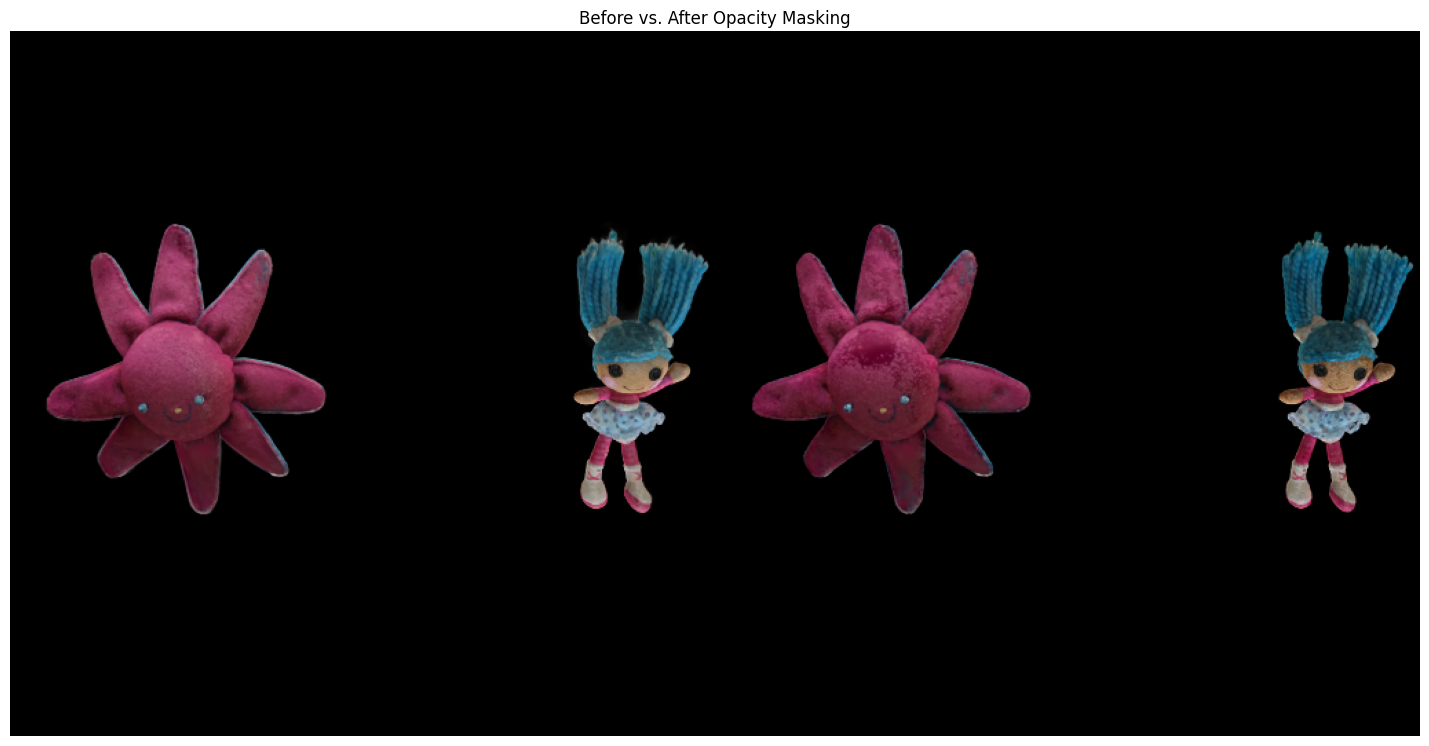

In [16]:
# Compare before and after masking side by side
colors_filtered, _, _ = render_with_gsplat(kaolin_cam, filtered)
quick_viz(
    torch.cat([colors, colors_filtered], dim=0).permute(0, 3, 1, 2),
    inches=20).set_title('Before vs. After Opacity Masking')

In [17]:
# Save the filtered model to disk
out_masked_ply = os.path.join('/tmp', 'combined_filtered.ply')
kaolin.io.ply.export_gaussiancloud(
    out_masked_ply,
    positions=filtered.positions,
    orientations=filtered.orientations,
    scales=filtered.scales,
    opacities=filtered.opacities,
    sh_coeff=filtered.sh_coeff,
    overwrite=True
)
print(f'Filtered model saved to {out_masked_ply}')

Filtered model saved to /tmp/combined_filtered.ply
